#Datos y requrimientos para realizar proyecto Competencia Power Liftting


* dataset

* Eda a dataset

* Graficas por Sexo

* Clasificacion

* Matriz corelación

* Regresion logistica

* metricas

* Definir x y Y

In [20]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# Leer el archivo CSV, omitiendo líneas mal formadas
df = pd.read_csv("openpowerlifting.csv", on_bad_lines='skip')
# Selecciona todas las filas y columnas específicas
opowerlifting_df = df.loc[:, ['Deadlift1Kg', 'Deadlift2Kg','Deadlift3Kg','TotalKg','Best3DeadliftKg','Wilks']]
display(opowerlifting_df)

/tmp/ipykernel_34204/1675025069.py:12: DtypeWarning: Columns (35) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("openpowerlifting.csv", on_bad_lines='skip')


,Deadlift1Kg,Deadlift2Kg,Deadlift3Kg,TotalKg,Best3DeadliftKg,Wilks
0,110.0,120.0,130.0,290.0,130.0,324.16
1,130.0,140.0,145.0,332.5,145.0,378.07
2,NaN,NaN,NaN,32.5,NaN,38.56
3,132.5,-140.0,-140.0,310.0,132.5,345.61
4,150.0,160.0,170.0,390.0,170.0,321.25
...,...,...,...,...,...,...
1423349,180.0,190.0,-195.0,452.5,190.0,327.07
1423350,140.0,160.0,170.0,375.0,170.0,304.16
1423351,160.0,170.0,180.0,440.0,180.0,274.48
1423352,NaN,NaN,NaN,NaN,NaN,NaN


### Matriz de Correlación para opowerlifting_df

Matriz de Correlación de opowerlifting_df:


,Deadlift1Kg,Deadlift2Kg,Deadlift3Kg,TotalKg,Best3DeadliftKg,Wilks
Deadlift1Kg,1.000000,0.115412,-0.070460,0.453955,0.531479,0.307736
Deadlift2Kg,0.115412,1.000000,0.141795,0.162569,0.221535,0.091039
Deadlift3Kg,-0.070460,0.141795,1.000000,-0.100441,-0.076600,-0.105416
TotalKg,0.453955,0.162569,-0.100441,1.000000,0.864799,0.881385
Best3DeadliftKg,0.531479,0.221535,-0.076600,0.864799,1.000000,0.607853
Wilks,0.307736,0.091039,-0.105416,0.881385,0.607853,1.000000


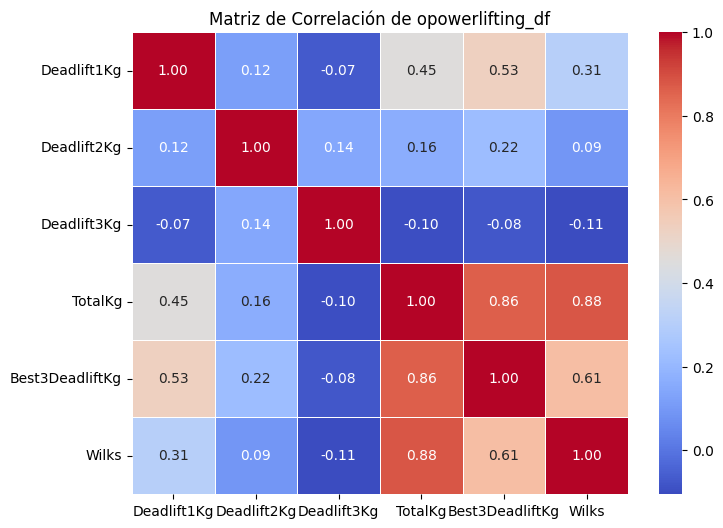

In [21]:
# Calcular la matriz de correlación para opowerlifting_df
correlation_matrix_opowerlifting = opowerlifting_df.corr()

print("Matriz de Correlación de opowerlifting_df:")
display(correlation_matrix_opowerlifting)

# Visualizar la matriz de correlación con un mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix_opowerlifting, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Matriz de Correlación de opowerlifting_df')
plt.show()

### Matriz de Correlación de Deadlift Separada por Sexo


--- Matriz de Correlación para Sexo: F ---


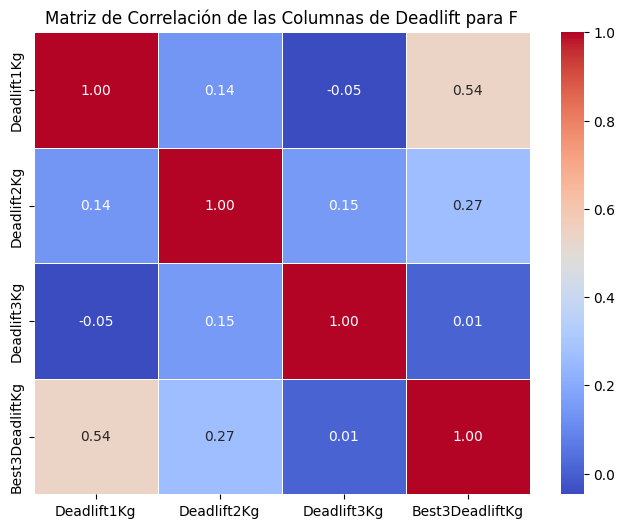


--- Matriz de Correlación para Sexo: M ---


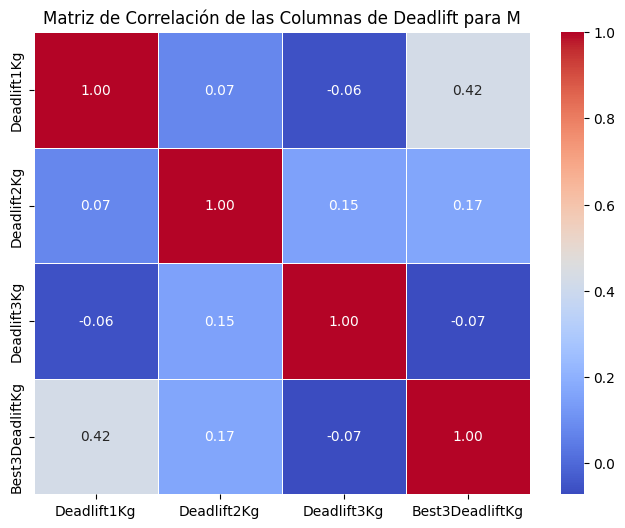

In [22]:
deadlift_cols_numerical = ['Deadlift1Kg', 'Deadlift2Kg', 'Deadlift3Kg', 'Best3DeadliftKg']

for sex_val in df['Sex'].unique():
    print(f"\n--- Matriz de Correlación para Sexo: {sex_val} ---")
    df_sex_filtered = df[df['Sex'] == sex_val]

    # Seleccionar solo las columnas de deadlift numéricas del DataFrame filtrado por sexo
    df_deadlift_corr_sex = df_sex_filtered[deadlift_cols_numerical]

    # Calcular la matriz de correlación
    correlation_matrix_sex = df_deadlift_corr_sex.corr()

    # Visualizar la matriz de correlación con un mapa de calor
    plt.figure(figsize=(8, 6))
    sns.heatmap(correlation_matrix_sex, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
    plt.title(f'Matriz de Correlación de las Columnas de Deadlift para {sex_val}')
    plt.show()

### Gráfica de Dispersión: 'Best3DeadliftKg' vs 'TotalKg'

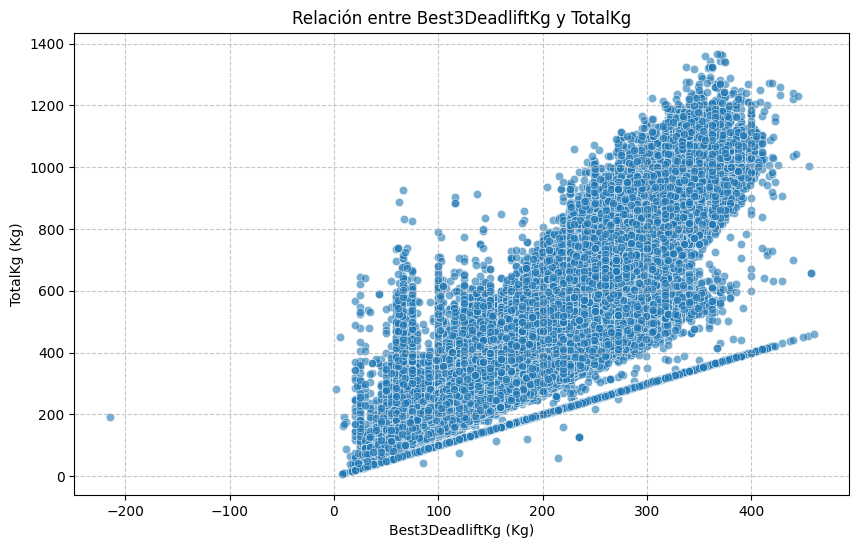

In [23]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Best3DeadliftKg', y='TotalKg', alpha=0.6)
plt.title('Relación entre Best3DeadliftKg y TotalKg')
plt.xlabel('Best3DeadliftKg (Kg)')
plt.ylabel('TotalKg (Kg)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [24]:
# 1. Calculamos las medianas
mediana_d1 = opowerlifting_df['Deadlift1Kg'].median()
mediana_d2 = opowerlifting_df['Deadlift2Kg'].median()
mediana_d3 = opowerlifting_df['Deadlift3Kg'].median()

# 2. Rellenamos los vacíos
opowerlifting_df['Deadlift1Kg'] = opowerlifting_df['Deadlift1Kg'].fillna(mediana_d1)
# ... repetir para d2 y d3

## Exploratory Data Analysis (EDA)

### Missing Values Analysis

In [38]:
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_info = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage
})

# Filter to show only columns with missing values
missing_info = missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False)

display(missing_info)

,Missing Count,Missing Percentage


Let's visualize the missing values using a heatmap.

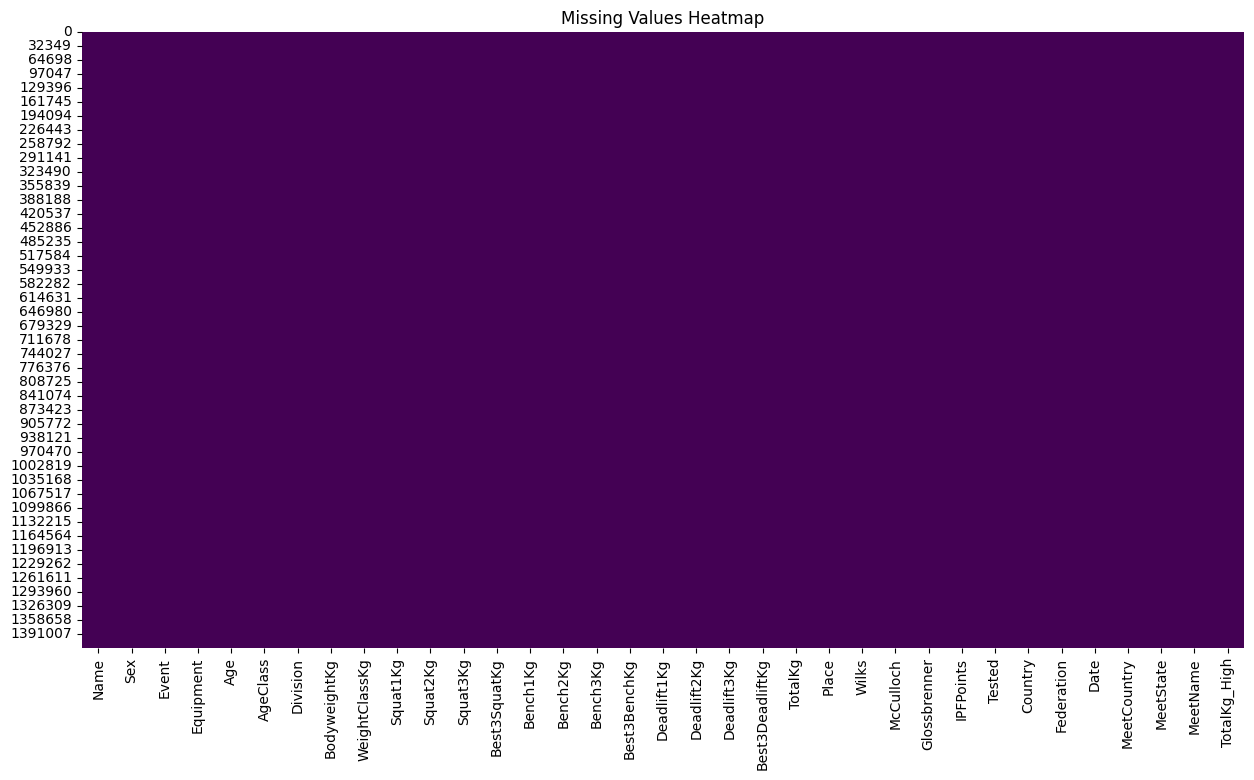

In [39]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

### Manejo de Valores Faltantes en Columnas de Deadlift

Las columnas `Deadlift1Kg`, `Deadlift2Kg`, `Deadlift3Kg` y `Best3DeadliftKg` fueron previamente imputadas con la mediana en la fase inicial del Manejo de Valores Faltantes. Por esta razón, el código ejecutado en el paso anterior (`fillna(0)`) no encontró valores `NaN` adicionales que rellenar en estas columnas, resultando en un `NaN count` final de 0.

In [40]:
deadlift_cols_to_fill_zero = ['Deadlift1Kg', 'Deadlift2Kg', 'Deadlift3Kg', 'Best3DeadliftKg']

# Fill NaN values with 0 in the specified columns
initial_nan_count = df[deadlift_cols_to_fill_zero].isnull().sum().sum()
df[deadlift_cols_to_fill_zero] = df[deadlift_cols_to_fill_zero].fillna(0)
final_nan_count = df[deadlift_cols_to_fill_zero].isnull().sum().sum()

print(f"Initial NaN count in {deadlift_cols_to_fill_zero}: {initial_nan_count}")
print(f"Final NaN count in {deadlift_cols_to_fill_zero} after filling with 0: {final_nan_count}")

Initial NaN count in ['Deadlift1Kg', 'Deadlift2Kg', 'Deadlift3Kg', 'Best3DeadliftKg']: 0
Final NaN count in ['Deadlift1Kg', 'Deadlift2Kg', 'Deadlift3Kg', 'Best3DeadliftKg'] after filling with 0: 0


### Manejo de Valores Faltantes

In [41]:
print('--- Recalculando información de valores faltantes para el DataFrame actual ---')
missing_values_current = df.isnull().sum()
missing_percentage_current = (df.isnull().sum() / len(df)) * 100

missing_info_current = pd.DataFrame({
    'Missing Count': missing_values_current,
    'Missing Percentage': missing_percentage_current
})
missing_info_current = missing_info_current[missing_info_current['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False)
display(missing_info_current)

# Identificar columnas para eliminar
columns_to_drop = missing_info_current[missing_info_current['Missing Percentage'] > 90].index.tolist()
if columns_to_drop:
    print(f"Columnas a eliminar (más del 90% de valores faltantes): {columns_to_drop}")
    df = df.drop(columns=columns_to_drop)
else:
    print("No hay columnas con más del 90% de valores faltantes para eliminar.")

# Imputar columnas numéricas con la mediana
# Seleccionar solo columnas que todavía existen en df
numerical_cols_after_drop = df.select_dtypes(include=np.number).columns
for col in numerical_cols_after_drop:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"Imputada la mediana ({median_val}) en columna numérica: {col}")

# Imputar columnas categóricas con la moda
# Seleccionar solo columnas que todavía existen en df
categorical_cols_after_drop = df.select_dtypes(include='object').columns
for col in categorical_cols_after_drop:
    if df[col].isnull().any():
        mode_val = df[col].mode()[0] # mode() can return multiple values, take the first one
        df[col] = df[col].fillna(mode_val)
        print(f"Imputada la moda ('{mode_val}') en columna categórica: {col}")

print("\n--- Verificación de valores faltantes después de la limpieza ---")
print(f"Total de valores faltantes en el DataFrame después de la limpieza: {df.isnull().sum().sum()}")

--- Recalculando información de valores faltantes para el DataFrame actual ---


,Missing Count,Missing Percentage


No hay columnas con más del 90% de valores faltantes para eliminar.

--- Verificación de valores faltantes después de la limpieza ---
Total de valores faltantes en el DataFrame después de la limpieza: 0


##'Distribución de Puntajes Wilks por Sexo'

La gráfica de distribución de los puntajes *Wilks* por sexo. Puedes observar la distribución de los puntajes Wilks para hombres y mujeres en el gráfico.


/tmp/ipykernel_34204/2777103367.py:7: DtypeWarning: Columns (35) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("openpowerlifting.csv", on_bad_lines='skip', dtype={'WeightClassKg': str})


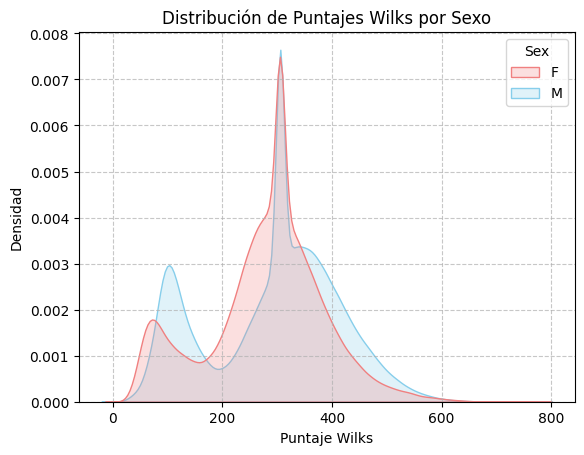

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Re-load df and apply essential cleaning as it was done previously
df = pd.read_csv("openpowerlifting.csv", on_bad_lines='skip', dtype={'WeightClassKg': str})

# --- Start of essential cleaning from 8a80bdf1 ---
missing_values_current = df.isnull().sum()
missing_percentage_current = (df.isnull().sum() / len(df)) * 100

missing_info_current = pd.DataFrame({
    'Missing Count': missing_values_current,
    'Missing Percentage': missing_percentage_current
})
missing_info_current = missing_info_current[missing_info_current['Missing Count'] > 0].sort_values(by='Missing Percentage', ascending=False)

columns_to_drop = missing_info_current[missing_info_current['Missing Percentage'] > 90].index.tolist()
if columns_to_drop:
    df = df.drop(columns=columns_to_drop)

numerical_cols_after_drop = df.select_dtypes(include=np.number).columns
for col in numerical_cols_after_drop:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)

categorical_cols_after_drop = df.select_dtypes(include='object').columns
for col in categorical_cols_after_drop:
    if df[col].isnull().any():
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)
# --- End of essential cleaning ---

sns.kdeplot(data=df, x='Wilks', hue='Sex', fill=True, common_norm=False, palette={'M': 'skyblue', 'F': 'lightcoral'})
plt.title('Distribución de Puntajes Wilks por Sexo')
plt.xlabel('Puntaje Wilks')
plt.ylabel('Densidad')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [30]:
print("Información del DataFrame después de la limpieza:")
df.info()

Información del DataFrame después de la limpieza:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1423354 entries, 0 to 1423353
Data columns (total 34 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   Name             1423354 non-null  object 
 1   Sex              1423354 non-null  object 
 2   Event            1423354 non-null  object 
 3   Equipment        1423354 non-null  object 
 4   Age              1423354 non-null  float64
 5   AgeClass         1423354 non-null  object 
 6   Division         1423354 non-null  object 
 7   BodyweightKg     1423354 non-null  float64
 8   WeightClassKg    1423354 non-null  object 
 9   Squat1Kg         1423354 non-null  float64
 10  Squat2Kg         1423354 non-null  float64
 11  Squat3Kg         1423354 non-null  float64
 12  Best3SquatKg     1423354 non-null  float64
 13  Bench1Kg         1423354 non-null  float64
 14  Bench2Kg         1423354 non-null  float64
 15  Bench3Kg        

### Categorical Feature Analysis
###Análisis de características categóricas

/tmp/ipykernel_34204/3995647442.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=df[col].value_counts().index, palette='viridis')


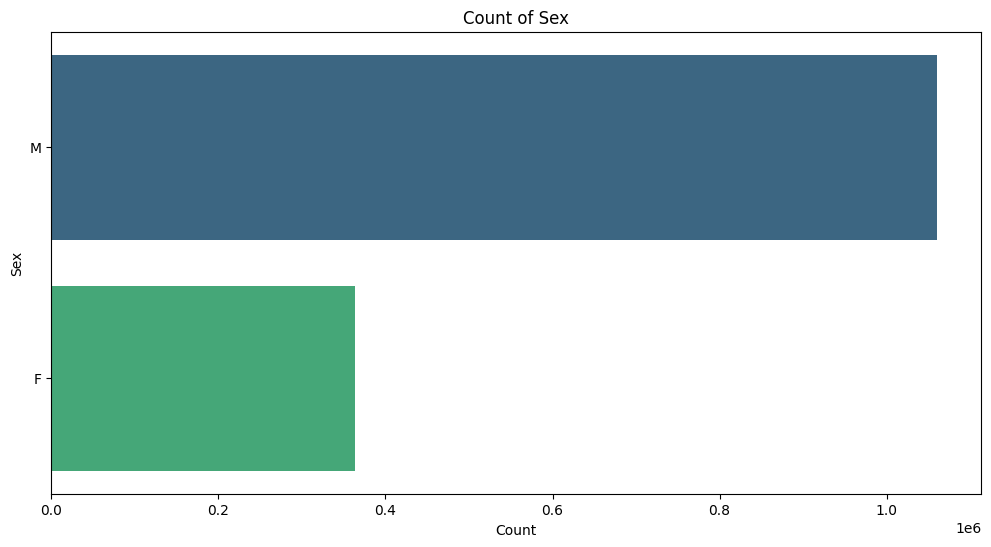

/tmp/ipykernel_34204/3995647442.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=df[col].value_counts().index, palette='viridis')


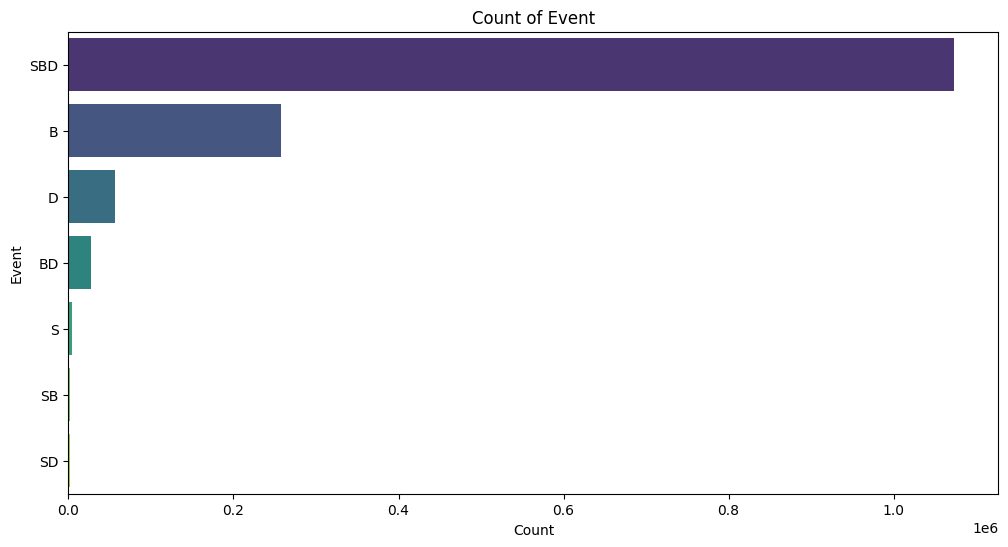

/tmp/ipykernel_34204/3995647442.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=df[col].value_counts().index, palette='viridis')


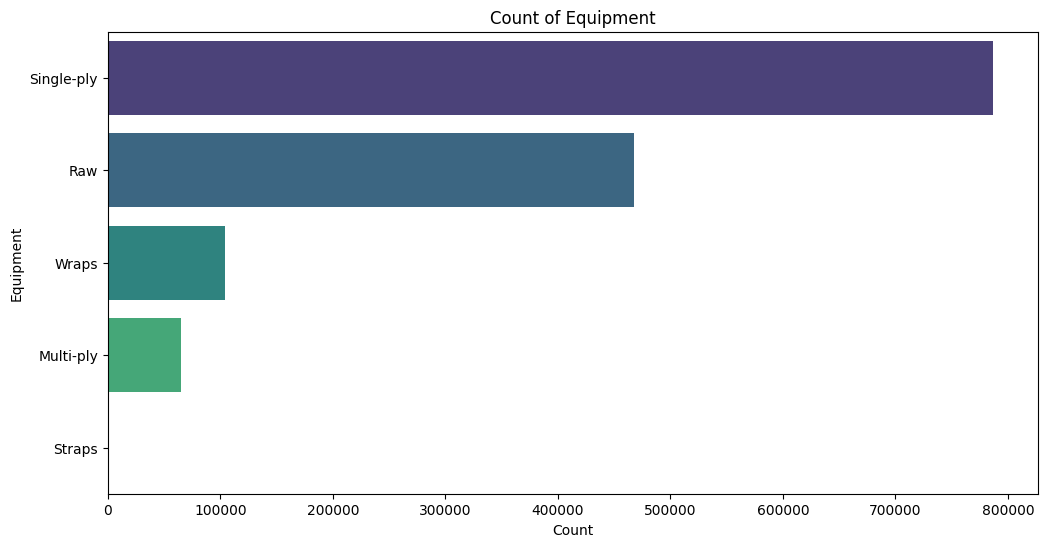

/tmp/ipykernel_34204/3995647442.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=df[col].value_counts().index, palette='viridis')


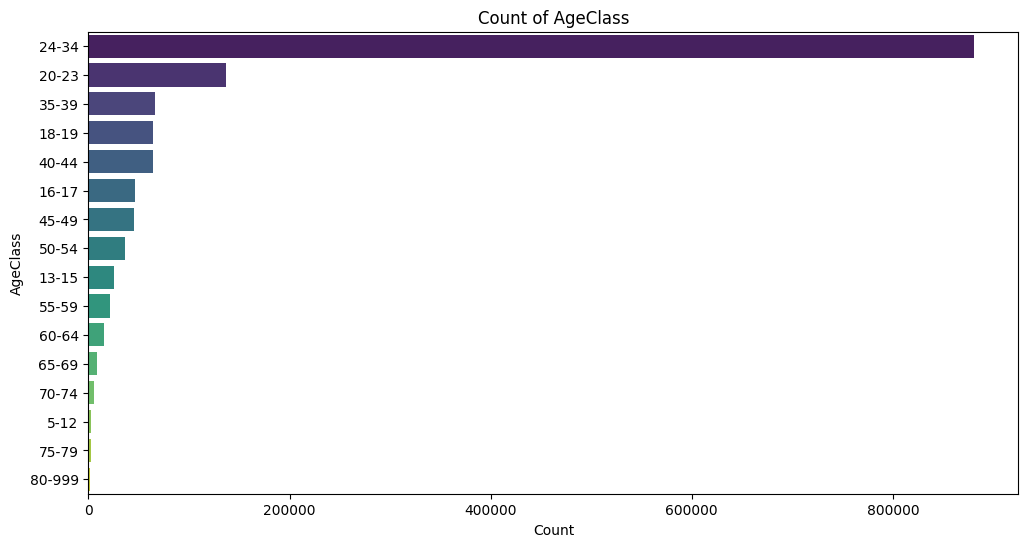

/tmp/ipykernel_34204/3995647442.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y=col, order=df[col].value_counts().index, palette='viridis')


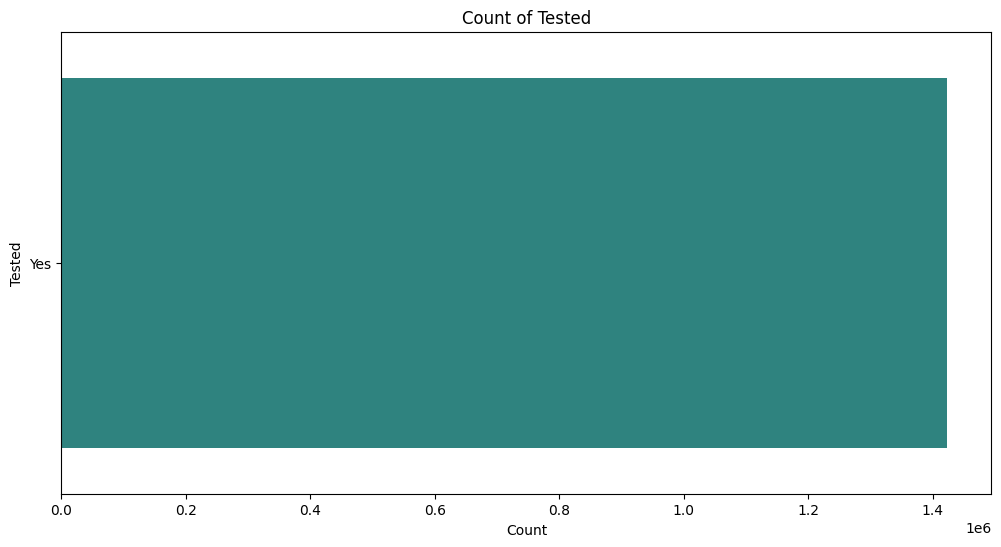

In [31]:
# Get categorical columns
categorical_cols = df.select_dtypes(include='object').columns

# Filter out columns that are unique identifiers or have too many unique values for a meaningful bar plot
# and also exclude columns with very high missing percentages if they are not useful
relevant_categorical_cols = [col for col in categorical_cols if df[col].nunique() < 50 and missing_percentage[col] < 90 and col not in ['Name', 'Date', 'MeetName']]

# Plot bar charts for categorical features
for col in relevant_categorical_cols:
    plt.figure(figsize=(12, 6))
    sns.countplot(data=df, y=col, order=df[col].value_counts().index, palette='viridis')
    plt.title(f'Count of {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
    plt.show()

### Análisis de Deadlift por Sexo

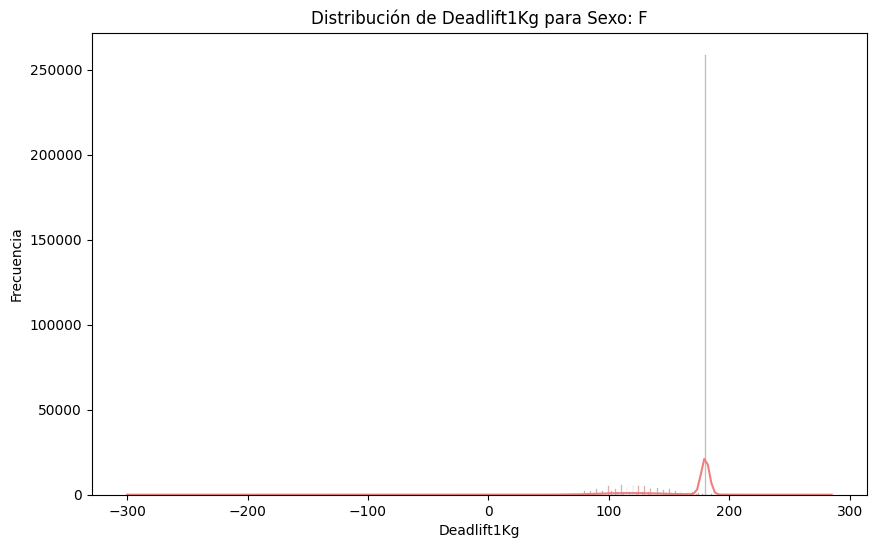

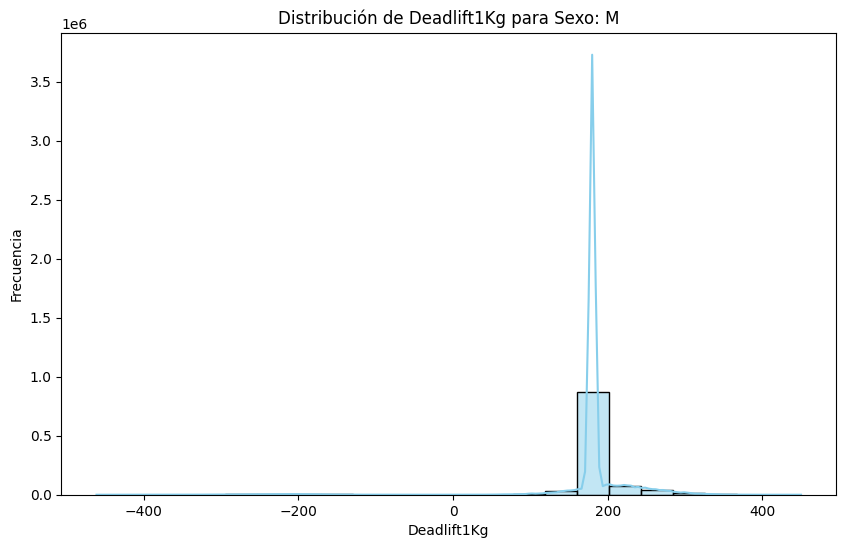

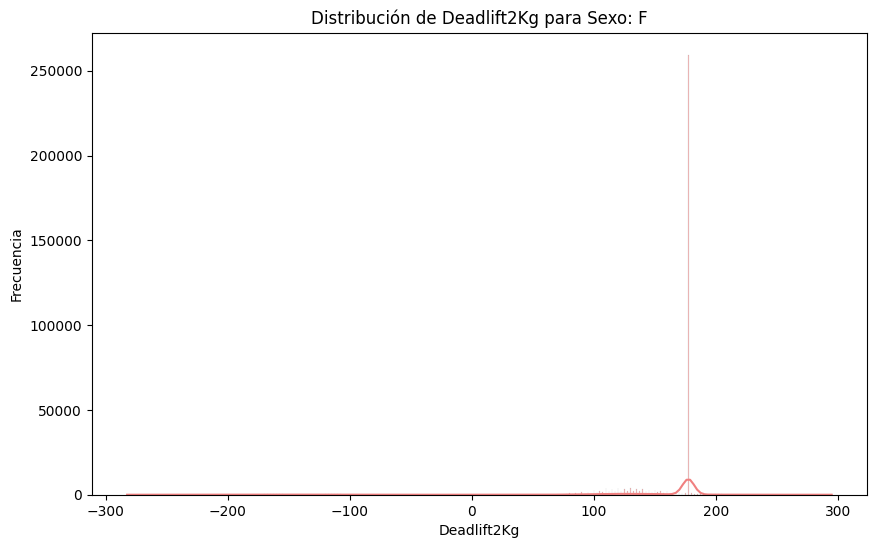

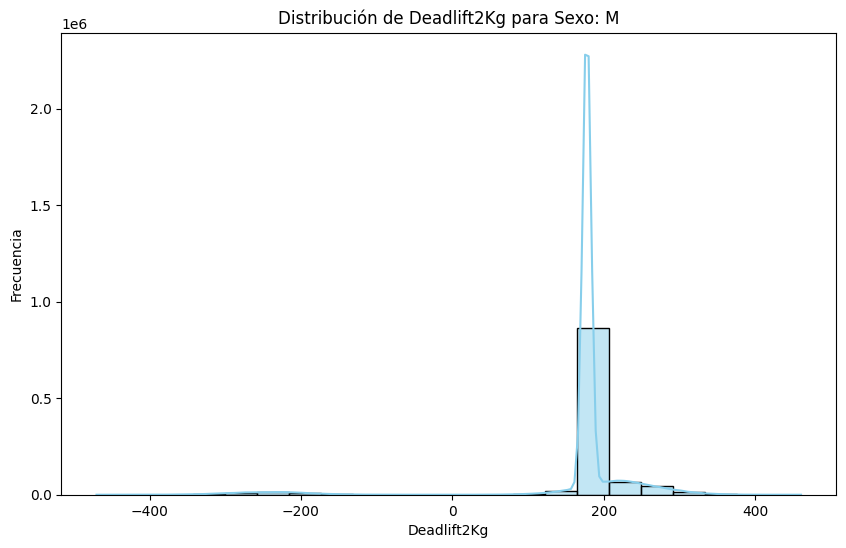

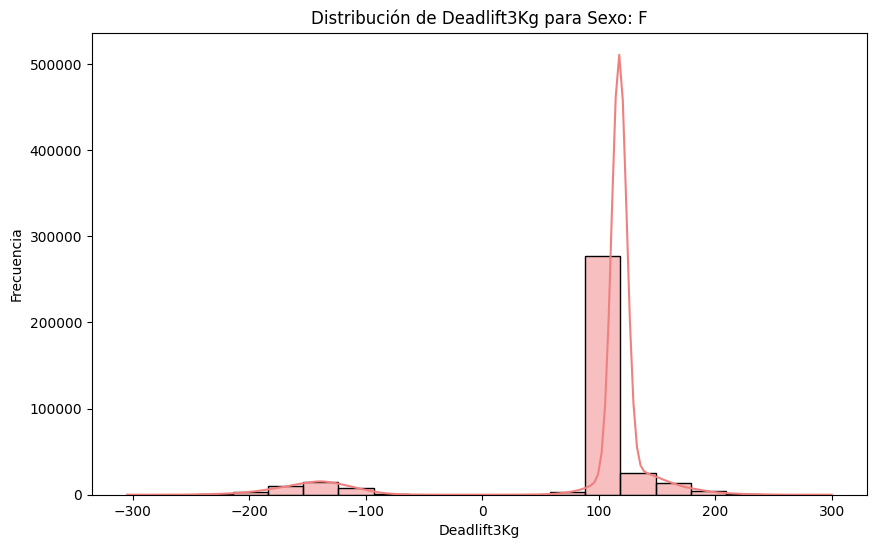

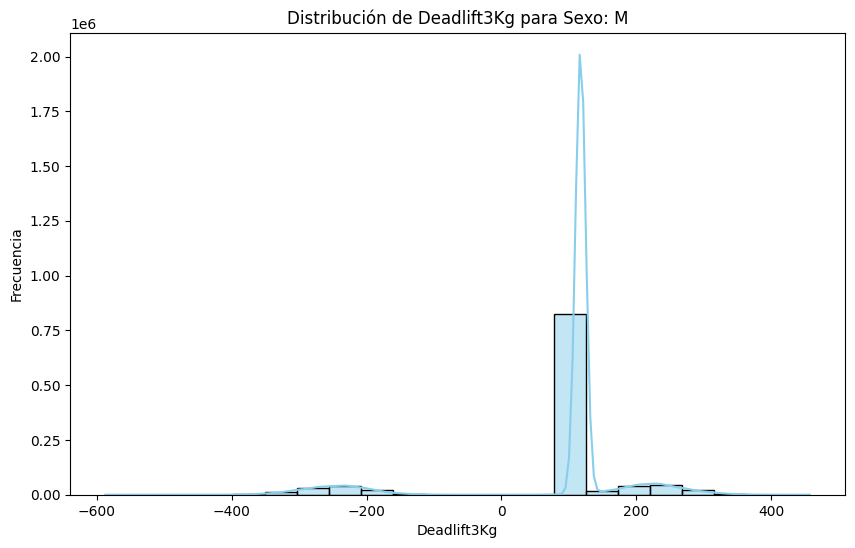

In [32]:
deadlift_cols = ['Deadlift1Kg', 'Deadlift2Kg', 'Deadlift3Kg']

for col in deadlift_cols:
    for sex_val in df['Sex'].unique():
        plt.figure(figsize=(10, 6))
        sns.histplot(data=df[df['Sex'] == sex_val], x=col, kde=True, color='skyblue' if sex_val == 'M' else 'lightcoral')
        plt.title(f'Distribución de {col} para Sexo: {sex_val}')
        plt.xlabel(col)
        plt.ylabel('Frecuencia')
        plt.show()

### Correlación entre todas las variables numéricas

Matriz de Correlación de todas las variables numéricas:


,Age,BodyweightKg,Squat1Kg,Squat2Kg,Squat3Kg,Best3SquatKg,Bench1Kg,Bench2Kg,Bench3Kg,Best3BenchKg,Deadlift1Kg,Deadlift2Kg,Deadlift3Kg,Best3DeadliftKg,TotalKg,Wilks,McCulloch,Glossbrenner,IPFPoints
Age,1.000000,0.124070,-0.003848,-0.000355,0.016026,0.009671,0.001803,-0.025418,0.007657,0.109391,0.015514,0.016085,0.013874,0.033949,-0.105598,-0.167645,-0.088860,-0.166351,0.051843
BodyweightKg,0.124070,1.000000,0.076734,0.060897,0.034120,0.501317,0.108224,0.050481,-0.018779,0.569460,0.145487,0.069689,-0.003875,0.501625,0.377044,0.026196,0.020592,0.044416,0.097544
Squat1Kg,-0.003848,0.076734,1.000000,0.189525,0.114909,0.164534,0.128649,0.091550,-0.002253,0.118095,0.178573,0.102765,0.042132,0.131106,0.091844,0.030062,0.019598,0.039537,0.085159
Squat2Kg,-0.000355,0.060897,0.189525,1.000000,0.196952,0.085169,0.104943,0.107809,0.001017,0.065070,0.140974,0.141024,0.111798,0.064540,0.021884,-0.032157,-0.041070,-0.024972,0.034835
Squat3Kg,0.016026,0.034120,0.114909,0.196952,1.000000,0.003990,0.075485,0.107040,0.000416,0.009484,0.080543,0.144968,0.185103,-0.015086,-0.057314,-0.095456,-0.100293,-0.091579,-0.023270
Best3SquatKg,0.009671,0.501317,0.164534,0.085169,0.003990,1.000000,0.122786,0.057343,0.028598,0.678627,0.211486,0.042968,-0.106748,0.810295,0.718308,0.466006,0.451542,0.502011,0.478046
Bench1Kg,0.001803,0.108224,0.128649,0.104943,0.075485,0.122786,1.000000,0.177533,-0.008825,0.196296,0.153315,0.079117,0.019417,0.124211,0.117786,0.045713,0.037783,0.056229,0.106453
Bench2Kg,-0.025418,0.050481,0.091550,0.107809,0.107040,0.057343,0.177533,1.000000,0.069304,0.082959,0.102993,0.095881,0.074227,0.057051,0.086769,0.051463,0.044881,0.057219,0.027264
Bench3Kg,0.007657,-0.018779,-0.002253,0.001017,0.000416,0.028598,-0.008825,0.069304,1.000000,0.042221,-0.005229,-0.002211,-0.027825,0.039990,0.030749,0.032254,0.040054,0.030902,0.083919
Best3BenchKg,0.109391,0.569460,0.118095,0.065070,0.009484,0.678627,0.196296,0.082959,0.042221,1.000000,0.178197,0.054738,-0.054287,0.668073,0.462948,0.175105,0.165656,0.215488,0.575040


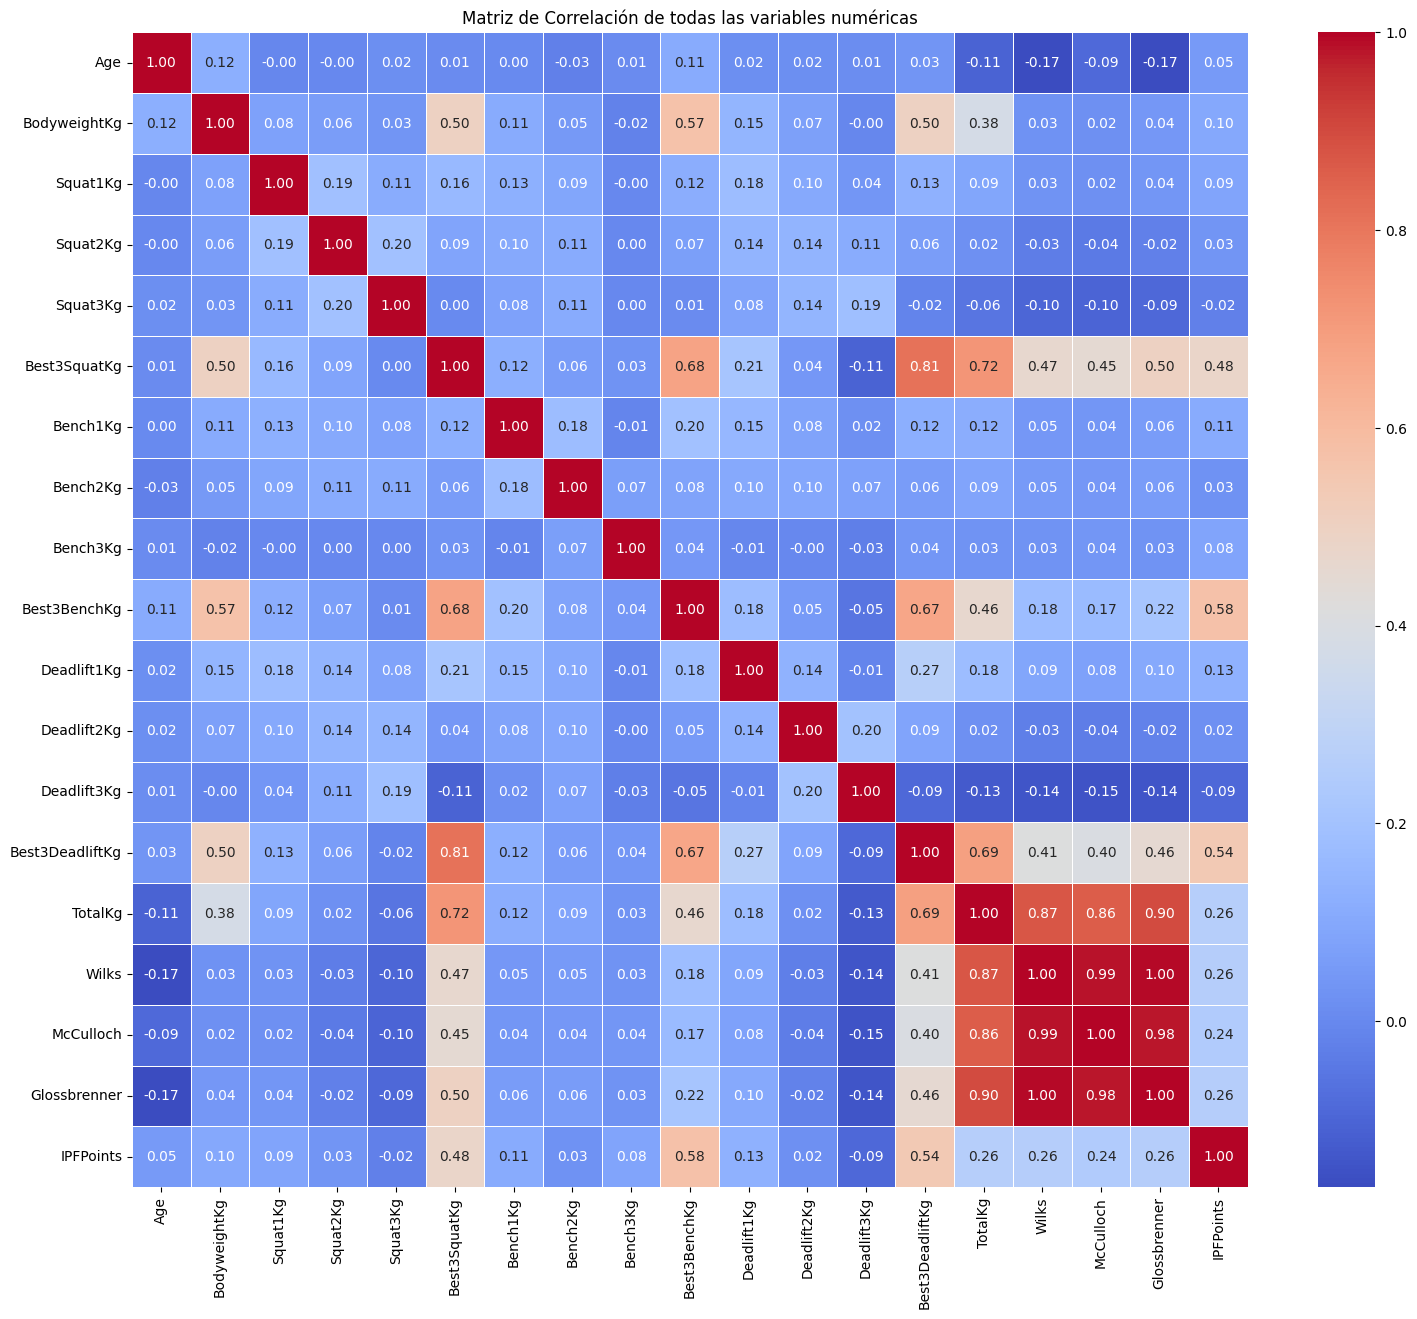

In [33]:
# Seleccionar solo las columnas numéricas
numerical_df = df.select_dtypes(include=np.number)

# Calcular la matriz de correlación
correlation_matrix_all = numerical_df.corr()

print("Matriz de Correlación de todas las variables numéricas:")
display(correlation_matrix_all)

# Visualizar la matriz de correlación con un mapa de calor
plt.figure(figsize=(18, 15))
sns.heatmap(correlation_matrix_all, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Matriz de Correlación de todas las variables numéricas')
plt.show()

### Preparación de Datos para Regresión Logística

In [34]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Crear una variable objetivo binaria: ¿TotalKg es alto o bajo?
# Usaremos la mediana como umbral para clasificar 'TotalKg'.
median_total_kg = df['TotalKg'].median()
df['TotalKg_High'] = (df['TotalKg'] > median_total_kg).astype(int)

print(f"Mediana de TotalKg utilizada como umbral: {median_total_kg}")
print("Distribución de la nueva variable objetivo 'TotalKg_High':")
print(df['TotalKg_High'].value_counts())

# Definir las características (X) y la variable objetivo (y)
# Seleccionamos algunas columnas numéricas como características.
# Excluimos 'TotalKg' y las columnas de Deadlift que son muy correlacionadas para evitar multicolinealidad con el objetivo.
features = ['Age', 'BodyweightKg', 'Wilks', 'McCulloch', 'Glossbrenner', 'IPFPoints',
            'Best3SquatKg', 'Best3BenchKg'] # Seleccionamos características relevantes

X = df[features]
y = df['TotalKg_High']

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nDimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de X_test: {X_test.shape}")
print(f"Dimensiones de y_train: {y_train.shape}")
print(f"Dimensiones de y_test: {y_test.shape}")


Mediana de TotalKg utilizada como umbral: 378.75
Distribución de la nueva variable objetivo 'TotalKg_High':
TotalKg_High
0    767680
1    655674
Name: count, dtype: int64

Dimensiones de X_train: (1138683, 8)
Dimensiones de X_test: (284671, 8)
Dimensiones de y_train: (1138683,)
Dimensiones de y_test: (284671,)


### Escalado de Características y Entrenamiento del Modelo

In [35]:
# Escalar las características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Inicializar y entrenar el modelo de regresión logística
logistic_model = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)
logistic_model.fit(X_train_scaled, y_train)

print("Modelo de regresión logística entrenado exitosamente.")

Modelo de regresión logística entrenado exitosamente.


### Evaluación del Modelo de Regresión Logística

In [36]:
# Realizar predicciones en el conjunto de prueba
y_pred = logistic_model.predict(X_test_scaled)

# Calcular y mostrar las métricas de precisión
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

print(f"Precisión del modelo: {accuracy:.4f}")
print("\nReporte de Clasificación:\n")
print(report)
print("\nMatriz de Confusión:\n")
print(conf_matrix)

Precisión del modelo: 0.9247

Reporte de Clasificación:

              precision    recall  f1-score   support

           0       0.93      0.93      0.93    153536
           1       0.92      0.92      0.92    131135

    accuracy                           0.92    284671
   macro avg       0.92      0.92      0.92    284671
weighted avg       0.92      0.92      0.92    284671


Matriz de Confusión:

[[142835  10701]
 [ 10730 120405]]


### Curva ROC y AUC para el Modelo de Regresión Logística

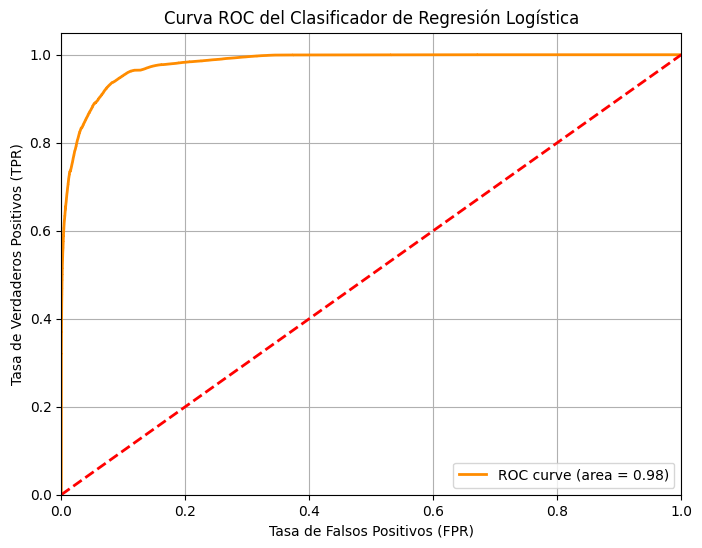

El Área Bajo la Curva (AUC) es: 0.9804


In [37]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Obtener las probabilidades predichas de la clase positiva (clase 1)
y_pred_proba = logistic_model.predict_proba(X_test_scaled)[:, 1]

# Calcular la curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plotear la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC del Clasificador de Regresión Logística')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

print(f"El Área Bajo la Curva (AUC) es: {roc_auc:.4f}")